In [ ]:
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("secareanualin/football-events")

print("Path to dataset files:", path)

100%|██████████| 21.1M/21.1M [00:00<00:00, 95.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/secareanualin/football-events/versions/1


In [ ]:
!ls {path}

dictionary.txt	events.csv  ginf.csv


In [ ]:
events_df = pd.read_csv(path + "/events.csv")
events_df.head()

,id_odsp,id_event,sort_order,time,text,event_type,event_type2,side,event_team,opponent,...,player_in,player_out,shot_place,shot_outcome,is_goal,location,bodypart,assist_method,situation,fast_break
0,UFot0hit/,UFot0hit1,1,2,Attempt missed. Mladen Petric (Hamburg) left f...,1,12.0,2,Hamburg SV,Borussia Dortmund,...,NaN,NaN,6.0,2.0,0,9.0,2.0,1,1.0,0
1,UFot0hit/,UFot0hit2,2,4,"Corner, Borussia Dortmund. Conceded by Dennis...",2,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
2,UFot0hit/,UFot0hit3,3,4,"Corner, Borussia Dortmund. Conceded by Heiko ...",2,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
3,UFot0hit/,UFot0hit4,4,7,Foul by Sven Bender (Borussia Dortmund).,3,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
4,UFot0hit/,UFot0hit5,5,7,Gokhan Tore (Hamburg) wins a free kick in the ...,8,NaN,2,Hamburg SV,Borussia Dortmund,...,NaN,NaN,NaN,NaN,0,2.0,NaN,0,NaN,0


In [ ]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 941009 entries, 0 to 941008
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id_odsp        941009 non-null  object 
 1   id_event       941009 non-null  object 
 2   sort_order     941009 non-null  int64  
 3   time           941009 non-null  int64  
 4   text           941009 non-null  object 
 5   event_type     941009 non-null  int64  
 6   event_type2    214293 non-null  float64
 7   side           941009 non-null  int64  
 8   event_team     941009 non-null  object 
 9   opponent       941009 non-null  object 
 10  player         880009 non-null  object 
 11  player2        291310 non-null  object 
 12  player_in      51715 non-null   object 
 13  player_out     51738 non-null   object 
 14  shot_place     227459 non-null  float64
 15  shot_outcome   228498 non-null  float64
 16  is_goal        941009 non-null  int64  
 17  location       467067 non-nul

In [ ]:
pd.set_option('display.max_rows', None)
events_df['event_team'].value_counts()

,count
event_team,
Juventus,12054
Fiorentina,11802
Real Madrid,11644
AC Milan,11633
AS Roma,11482
Genoa,11474
Lazio,11362
Lille,11347
Atalanta,11288


In [ ]:
ManchesterUtd_df = events_df[events_df['event_team'] == 'Manchester Utd']
ManchesterUtd_df.head()

,id_odsp,id_event,sort_order,time,text,event_type,event_type2,side,event_team,opponent,...,player_in,player_out,shot_place,shot_outcome,is_goal,location,bodypart,assist_method,situation,fast_break
331463,j7h8TOAt/,j7h8TOAt2,2,5,Foul by Robin van Persie (Manchester United).,3,NaN,2,Manchester Utd,Sunderland,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
331465,j7h8TOAt/,j7h8TOAt4,4,12,"Corner, Manchester United. Conceded by Valent...",2,NaN,2,Manchester Utd,Sunderland,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
331466,j7h8TOAt/,j7h8TOAt5,5,12,Attempt missed. Nani (Manchester United) right...,1,12.0,2,Manchester Utd,Sunderland,...,NaN,NaN,8.0,2.0,0,15.0,1.0,1,1.0,0
331468,j7h8TOAt/,j7h8TOAt7,7,13,Attempt blocked. Adnan Januzaj (Manchester Uni...,1,NaN,2,Manchester Utd,Sunderland,...,NaN,NaN,2.0,3.0,0,15.0,2.0,0,1.0,0
331469,j7h8TOAt/,j7h8TOAt8,8,14,Foul by Adnan Januzaj (Manchester United).,3,NaN,2,Manchester Utd,Sunderland,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0


In [ ]:
manchester_utd_match_ids = events_df[(events_df['event_team'] == 'Manchester Utd') | (events_df['opponent'] == 'Manchester Utd')]['id_odsp'].unique()
print(f"Number of unique match IDs involving Manchester United: {len(manchester_utd_match_ids)}")

Number of unique match IDs involving Manchester United: 130


In [ ]:
mu_all_matches_events_df = events_df[events_df['id_odsp'].isin(manchester_utd_match_ids)].copy()
mu_all_matches_events_df['is_manchester_utd_event'] = (mu_all_matches_events_df['event_team'] == 'Manchester Utd')
print(f"Number of events in Manchester United related matches: {len(mu_all_matches_events_df)}")
mu_all_matches_events_df.head()

Number of events in Manchester United related matches: 11729


,id_odsp,id_event,sort_order,time,text,event_type,event_type2,side,event_team,opponent,...,player_out,shot_place,shot_outcome,is_goal,location,bodypart,assist_method,situation,fast_break,is_manchester_utd_event
331462,j7h8TOAt/,j7h8TOAt1,1,3,Ondrej Celustka (Sunderland) wins a free kick ...,8,NaN,1,Sunderland,Manchester Utd,...,NaN,NaN,NaN,0,5.0,NaN,0,NaN,0,False
331463,j7h8TOAt/,j7h8TOAt2,2,5,Foul by Robin van Persie (Manchester United).,3,NaN,2,Manchester Utd,Sunderland,...,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0,True
331464,j7h8TOAt/,j7h8TOAt3,3,7,"Goal! Sunderland 1, Manchester United 0. Crai...",1,NaN,1,Sunderland,Manchester Utd,...,NaN,3.0,1.0,1,3.0,1.0,0,1.0,0,False
331465,j7h8TOAt/,j7h8TOAt4,4,12,"Corner, Manchester United. Conceded by Valent...",2,NaN,2,Manchester Utd,Sunderland,...,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0,True
331466,j7h8TOAt/,j7h8TOAt5,5,12,Attempt missed. Nani (Manchester United) right...,1,12.0,2,Manchester Utd,Sunderland,...,NaN,8.0,2.0,0,15.0,1.0,1,1.0,0,True


## Bangun Model Expected Goals (xG)

### Subtask:
Filter the dataset to include only 'shot' events, define 'is_goal' as the target variable and selected event characteristics as features. Train a classification model (Logistic Regression or Gradient Boosting) to predict the probability of a goal (xG) for each shot and store the resulting xG values back into the main dataset.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# 1. Filter the mu_all_matches_events_df DataFrame to keep only 'shot' events (event_type == 1)
shot_events_df = mu_all_matches_events_df[mu_all_matches_events_df['event_type'] == 1].copy()

# 2. Define the target variable y as the is_goal column
y = shot_events_df['is_goal']

# 3. Select the specified columns as features for your model
feature_columns = ['shot_place', 'location', 'bodypart', 'situation', 'assist_method', 'fast_break', 'time']
X = shot_events_df[feature_columns].copy()

print(f"Number of shot events: {len(shot_events_df)}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("First 5 rows of X:")
print(X.head())

Number of shot events: 3121
Shape of X: (3121, 7)
Shape of y: (3121,)
First 5 rows of X:
        shot_place  location  bodypart  situation  assist_method  fast_break  \
331464         3.0       3.0       1.0        1.0              0           0   
331466         8.0      15.0       1.0        1.0              1           0   
331468         2.0      15.0       2.0        1.0              0           0   
331474         8.0      15.0       1.0        1.0              1           0   
331476         2.0      15.0       1.0        1.0              0           0   

        time  
331464     7  
331466    12  
331468    13  
331474    19  
331476    21  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Define categorical and numerical features
categorical_features = ['shot_place', 'location', 'bodypart', 'situation', 'assist_method']
numerical_features = ['fast_break', 'time']

# Preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)), # Using -1 for missing categorical values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a pipeline that first preprocesses the data and then trains a Logistic Regression model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(solver='liblinear', random_state=42))])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Training accuracy: {model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {model.score(X_test, y_test):.4f}")

Model training complete.
Training accuracy: 0.9395
Test accuracy: 0.9296


In [ ]:
import numpy as np

# Predict the probability of a goal (xG) for each shot event
xG_predictions = model.predict_proba(X)[:, 1]

# Create a new 'xG' column in the original mu_all_matches_events_df, initialized to 0
mu_all_matches_events_df['xG'] = 0.0

# Assign predicted xG values to the corresponding shot events in the main DataFrame
# Use .loc for safe assignment to avoid SettingWithCopyWarning
mu_all_matches_events_df.loc[shot_events_df.index, 'xG'] = xG_predictions

print("xG predictions calculated and added to mu_all_matches_events_df.")
print("First 5 rows of mu_all_matches_events_df with xG:")
print(mu_all_matches_events_df[['id_event', 'event_type', 'is_goal', 'xG']].head())

xG predictions calculated and added to mu_all_matches_events_df.
First 5 rows of mu_all_matches_events_df with xG:
         id_event  event_type  is_goal        xG
331462  j7h8TOAt1           8        0  0.000000
331463  j7h8TOAt2           3        0  0.000000
331464  j7h8TOAt3           1        1  0.547444
331465  j7h8TOAt4           2        0  0.000000
331466  j7h8TOAt5           1        0  0.000867


## Transformasi Data ke Interval 5 Menit

### Subtask:
Transform the event data into 5-minute intervals per match, focusing on Manchester United's actions. Calculate cumulative statistics such as shots, xG, and fast breaks, along with the goals scored within each interval.


In [ ]:
import numpy as np

# Filter for Manchester United's events only
mu_events_only_df = mu_all_matches_events_df[mu_all_matches_events_df['is_manchester_utd_event']].copy()

# Define 5-minute time intervals. The ceiling ensures the interval includes the current minute.
mu_events_only_df['minute_interval'] = (np.ceil(mu_events_only_df['time'] / 5) * 5).astype(int)

# Ensure minute_interval doesn't exceed 100
mu_events_only_df['minute_interval'] = mu_events_only_df['minute_interval'].clip(upper=100)

# Initialize columns for interval statistics
mu_events_only_df['shots_in_interval'] = (mu_events_only_df['event_type'] == 1).astype(int)
mu_events_only_df['xG_in_interval'] = mu_events_only_df['xG']
mu_events_only_df['fast_breaks_in_interval'] = mu_events_only_df['fast_break']

print(f"Number of Manchester United's events: {len(mu_events_only_df)}")
print("First 5 rows of Manchester United's events with minute interval:")
print(mu_events_only_df[['id_odsp', 'time', 'minute_interval', 'event_type', 'is_goal', 'xG', 'fast_break', 'shots_in_interval', 'xG_in_interval', 'fast_breaks_in_interval']].head())

Number of Manchester United's events: 6215
First 5 rows of Manchester United's events with minute interval:
          id_odsp  time  minute_interval  event_type  is_goal        xG  \
331463  j7h8TOAt/     5                5           3        0  0.000000   
331465  j7h8TOAt/    12               15           2        0  0.000000   
331466  j7h8TOAt/    12               15           1        0  0.000867   
331468  j7h8TOAt/    13               15           1        0  0.001582   
331469  j7h8TOAt/    14               15           3        0  0.000000   

        fast_break  shots_in_interval  xG_in_interval  fast_breaks_in_interval  
331463           0                  0        0.000000                        0  
331465           0                  0        0.000000                        0  
331466           0                  1        0.000867                        0  
331468           0                  1        0.001582                        0  
331469           0                  

In [ ]:
interval_stats = mu_events_only_df.groupby(['id_odsp', 'minute_interval']).agg(
    goals_in_interval=('is_goal', 'sum'),
    interval_shots=('shots_in_interval', 'sum'),
    interval_xG=('xG_in_interval', 'sum'),
    interval_fast_break=('fast_breaks_in_interval', 'sum')
).reset_index()

print("Aggregated interval statistics:")
print(interval_stats.head())

Aggregated interval statistics:
     id_odsp  minute_interval  goals_in_interval  interval_shots  interval_xG  \
0  0GdvciNJ/                0                  0               0     0.000000   
1  0GdvciNJ/                5                  0               0     0.000000   
2  0GdvciNJ/               10                  0               1     0.002402   
3  0GdvciNJ/               15                  0               1     0.001335   
4  0GdvciNJ/               20                  0               0     0.000000   

   interval_fast_break  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


In [ ]:
interval_stats['cumulative_goals'] = interval_stats.groupby('id_odsp')['goals_in_interval'].cumsum()
interval_stats['cumulative_shots'] = interval_stats.groupby('id_odsp')['interval_shots'].cumsum()
interval_stats['cumulative_xG'] = interval_stats.groupby('id_odsp')['interval_xG'].cumsum()
interval_stats['cumulative_fast_break'] = interval_stats.groupby('id_odsp')['interval_fast_break'].cumsum()

print("Aggregated interval statistics with cumulative sums:")
print(interval_stats.head())

Aggregated interval statistics with cumulative sums:
     id_odsp  minute_interval  goals_in_interval  interval_shots  interval_xG  \
0  0GdvciNJ/                0                  0               0     0.000000   
1  0GdvciNJ/                5                  0               0     0.000000   
2  0GdvciNJ/               10                  0               1     0.002402   
3  0GdvciNJ/               15                  0               1     0.001335   
4  0GdvciNJ/               20                  0               0     0.000000   

   interval_fast_break  cumulative_goals  cumulative_shots  cumulative_xG  \
0                    0                 0                 0       0.000000   
1                    0                 0                 0       0.000000   
2                    0                 0                 1       0.002402   
3                    0                 0                 2       0.003737   
4                    0                 0                 2       0.003737  

In [ ]:
mu_side_in_match_df = mu_events_only_df.groupby('id_odsp')['side'].first().reset_index()
mu_side_in_match_df = mu_side_in_match_df.rename(columns={'side': 'mu_side_in_match'})

interval_stats = pd.merge(interval_stats, mu_side_in_match_df, on='id_odsp', how='left')

print("Interval statistics with Manchester United's side in match:")
print(interval_stats.head())

Interval statistics with Manchester United's side in match:
     id_odsp  minute_interval  goals_in_interval  interval_shots  interval_xG  \
0  0GdvciNJ/                0                  0               0     0.000000   
1  0GdvciNJ/                5                  0               0     0.000000   
2  0GdvciNJ/               10                  0               1     0.002402   
3  0GdvciNJ/               15                  0               1     0.001335   
4  0GdvciNJ/               20                  0               0     0.000000   

   interval_fast_break  cumulative_goals  cumulative_shots  cumulative_xG  \
0                    0                 0                 0       0.000000   
1                    0                 0                 0       0.000000   
2                    0                 0                 1       0.002402   
3                    0                 0                 2       0.003737   
4                    0                 0                 2       0.0

In [ ]:
minute_interval_df = interval_stats[[ 'id_odsp', 'minute_interval', 'mu_side_in_match', 'cumulative_goals', 'cumulative_shots', 'cumulative_xG', 'cumulative_fast_break', 'goals_in_interval']].copy()

print("Final minute_interval_df:")
print(minute_interval_df.head())
print(minute_interval_df.info())

Final minute_interval_df:
     id_odsp  minute_interval  mu_side_in_match  cumulative_goals  \
0  0GdvciNJ/                0                 2                 0   
1  0GdvciNJ/                5                 2                 0   
2  0GdvciNJ/               10                 2                 0   
3  0GdvciNJ/               15                 2                 0   
4  0GdvciNJ/               20                 2                 0   

   cumulative_shots  cumulative_xG  cumulative_fast_break  goals_in_interval  
0                 0       0.000000                      0                  0  
1                 0       0.000000                      0                  0  
2                 1       0.002402                      0                  0  
3                 2       0.003737                      0                  0  
4                 2       0.003737                      0                  0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2268 entries, 0 to 2267
Data column

## Fit Time-Varying Poisson Regression

### Subtask:
Train a Poisson Regression model to predict 'goals_in_interval', incorporating 'minute_interval' as a time-varying feature, along with other cumulative statistics and match-specific information.


In [ ]:
import statsmodels.api as sm

# 1. Define the target variable y
y = minute_interval_df['goals_in_interval']

# 2. Select the features for the model
X = minute_interval_df[['minute_interval', 'mu_side_in_match', 'cumulative_shots', 'cumulative_xG', 'cumulative_fast_break']]

# 3. Add a constant term to the feature DataFrame X
X = sm.add_constant(X)

# 4. Instantiate and fit a Generalized Linear Model (GLM) with a Poisson family
poisson_model = sm.GLM(y, X, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

# 5. Print the model's summary
print(poisson_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      goals_in_interval   No. Observations:                 2268
Model:                            GLM   Df Residuals:                     2262
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -625.30
Date:                Thu, 05 Mar 2026   Deviance:                       857.52
Time:                        05:27:09   Pearson chi2:                 1.92e+03
No. Iterations:                     7   Pseudo R-squ. (CS):            0.05474
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.67

## Simulasi Monte Carlo

### Subtask:
Lakukan simulasi Monte Carlo sebanyak 10.000 pertandingan. Untuk setiap interval waktu dalam simulasi, sampel jumlah gol dari distribusi Poisson dengan λ yang diprediksi oleh model. Rekam total gol per pertandingan dan distribusi menit terjadinya gol. Hitung probabilitas Manchester United mencetak 0, 1, 2, 3+ gol, distribusi probabilitas menit gol, dan probabilitas mencetak gol dalam 10 menit ke depan dari menit tertentu.


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Pre-calculate average interval contributions (non-cumulative) for updating cumulative features during simulation.
# These are the average 'interval_shots', 'interval_xG', 'interval_fast_break' per 5-minute block.
avg_interval_contribution = interval_stats.groupby('minute_interval')[['interval_shots', 'interval_xG', 'interval_fast_break']].mean()

# Pre-calculate mean cumulative stats at the end of each interval from the minute_interval_df.
# This will be used to initialize cumulative stats for the 10-minute probability function.
mean_cumulative_stats_at_interval_end = minute_interval_df.groupby('minute_interval')[['cumulative_shots', 'cumulative_xG', 'cumulative_fast_break']].mean()

N_SIMULATIONS = 10000
SIMULATION_INTERVAL_STEP = 5
MAX_PREDICTION_MINUTE = 100 # Model is trained on minute_interval up to 100

all_simulated_goals_per_match = []
all_goal_minutes_recorded = []

print(f"Starting {N_SIMULATIONS} Monte Carlo simulations...")

for sim_num in range(N_SIMULATIONS):
    current_match_goals = 0
    current_match_goal_minutes = []

    # Initialize cumulative stats for the *start* of the first interval (minute 0)
    cumulative_shots_at_start_of_interval = 0
    cumulative_xG_at_start_of_interval = 0.0
    cumulative_fast_break_at_start_of_interval = 0

    # Assume Manchester United plays away (side = 2) for all simulations for consistency with model training context.
    mu_side_sim = 2

    # Loop through the *end* of each 5-minute interval (e.g., 5, 10, ..., 100)
    # This corresponds to the 'minute_interval' feature in the Poisson model.
    for current_interval_end_minute in range(SIMULATION_INTERVAL_STEP, MAX_PREDICTION_MINUTE + SIMULATION_INTERVAL_STEP, SIMULATION_INTERVAL_STEP):

        # Create current match state for prediction
        # Features (cumulative_shots, etc.) should reflect the state *before* this interval begins.
        current_X_data = {
            'const': 1,
            'minute_interval': current_interval_end_minute,
            'mu_side_in_match': mu_side_sim,
            'cumulative_shots': cumulative_shots_at_start_of_interval,
            'cumulative_xG': cumulative_xG_at_start_of_interval,
            'cumulative_fast_break': cumulative_fast_break_at_start_of_interval
        }
        # Ensure column order matches the model's training data 'X'
        current_X = pd.DataFrame([current_X_data], columns=poisson_results.model.exog_names)

        # Predict lambda (expected number of goals) for this interval
        lambda_pred = poisson_results.predict(current_X)[0]

        # Sample goals for this interval from a Poisson distribution
        goals_scored_this_interval = np.random.poisson(lambda_pred)

        current_match_goals += goals_scored_this_interval
        if goals_scored_this_interval > 0:
            # Record goal minutes, distributing them randomly within the current 5-minute interval.
            interval_start_minute = current_interval_end_minute - SIMULATION_INTERVAL_STEP
            for _ in range(goals_scored_this_interval):
                # Random minute between interval_start_minute (inclusive) and current_interval_end_minute (inclusive)
                goal_minute = np.random.randint(interval_start_minute, current_interval_end_minute + 1)
                # Ensure goal_minute is not 0, if the interval started at 0.
                if goal_minute == 0:
                    goal_minute = 1
                current_match_goal_minutes.append(goal_minute)

        # Update cumulative stats for the *start* of the *next* interval.
        # Add the average non-cumulative interval contributions from the observed data.
        if current_interval_end_minute in avg_interval_contribution.index:
            cumulative_shots_at_start_of_interval += avg_interval_contribution.loc[current_interval_end_minute, 'interval_shots']
            cumulative_xG_at_start_of_interval += avg_interval_contribution.loc[current_interval_end_minute, 'interval_xG']
            cumulative_fast_break_at_start_of_interval += avg_interval_contribution.loc[current_interval_end_minute, 'interval_fast_break']

    all_simulated_goals_per_match.append(current_match_goals)
    all_goal_minutes_recorded.extend(current_match_goal_minutes)

print("Monte Carlo simulation complete.")
print(f"Total simulated goals across all matches: {sum(all_simulated_goals_per_match)}")
print(f"Number of recorded goal minutes: {len(all_goal_minutes_recorded)}")


# --- Analyze simulation results ---

# 8. Calculate the probability of Manchester United scoring 0, 1, 2, 3+ goals
total_matches = N_SIMULATIONS
goals_counts = pd.Series(all_simulated_goals_per_match).value_counts().sort_index()

prob_0_goals = goals_counts.get(0, 0) / total_matches
prob_1_goal = goals_counts.get(1, 0) / total_matches
prob_2_goals = goals_counts.get(2, 0) / total_matches
prob_3plus_goals = goals_counts[goals_counts.index >= 3].sum() / total_matches if any(goals_counts.index >= 3) else 0.0

print("\n--- Goal Probabilities (Manchester United) ---")
print(f"P(Goals = 0): {prob_0_goals:.4f}")
print(f"P(Goals = 1): {prob_1_goal:.4f}")
print(f"P(Goals = 2): {prob_2_goals:.4f}")
print(f"P(Goals >= 3): {prob_3plus_goals:.4f}")
print(f"Sum of probabilities: {prob_0_goals + prob_1_goal + prob_2_goals + prob_3plus_goals:.4f}")

# 9. Create a distribution of goal minutes
goal_minutes_series = pd.Series(all_goal_minutes_recorded)
# Filter out potential goal_minute = 0 if any slipped through
goal_minutes_series = goal_minutes_series[goal_minutes_series > 0]
goal_minutes_distribution = goal_minutes_series.value_counts(normalize=True).sort_index()

print("\n--- Goal Minute Distribution (Top 10 most frequent minutes) ---")
print(goal_minutes_distribution.head(10))

# 10. Calculate probability of scoring a goal in the next 10 minutes from a given minute.
# This function estimates the probability using the trained Poisson model and average cumulative stats.
def predict_goal_probability_next_10_min(current_minute, mu_side_in_match, model, mean_cumulative_stats_df, avg_interval_contribution_df):
    """
    Estimates the probability of scoring at least one goal in the next 10 minutes
    from the current_minute, assuming average cumulative stats.
    """
    total_lambda_for_10_min = 0.0

    # Determine the end minutes of the next two 5-minute intervals.
    first_interval_end = int(np.ceil((current_minute + 1) / SIMULATION_INTERVAL_STEP) * SIMULATION_INTERVAL_STEP)
    second_interval_end = first_interval_end + SIMULATION_INTERVAL_STEP

    intervals_to_predict = []
    if first_interval_end <= MAX_PREDICTION_MINUTE:
        intervals_to_predict.append(first_interval_end)
    if second_interval_end <= MAX_PREDICTION_MINUTE:
        intervals_to_predict.append(second_interval_end)

    if not intervals_to_predict:
        return 0.0 # No more intervals to predict goals within 10 minutes

    # Get the average cumulative stats representing the state *at* the current_minute.
    # Find the closest observed minute_interval *before or equal to* current_minute for initial cumulative stats.
    relevant_interval_for_stats = mean_cumulative_stats_df.index[mean_cumulative_stats_df.index <= current_minute].max()

    if pd.isna(relevant_interval_for_stats) or relevant_interval_for_stats == 0:
        # If current_minute is before any observed interval (e.g., 0-5), use initial 0s
        cum_shots_for_prediction = 0
        cum_xG_for_prediction = 0.0
        cum_fast_break_for_prediction = 0
    else:
        cum_stats_at_current_minute_avg = mean_cumulative_stats_df.loc[relevant_interval_for_stats]
        cum_shots_for_prediction = cum_stats_at_current_minute_avg['cumulative_shots']
        cum_xG_for_prediction = cum_stats_at_current_minute_avg['cumulative_xG']
        cum_fast_break_for_prediction = cum_stats_at_current_minute_avg['cumulative_fast_break']

    # Predict lambda for each of the next two 5-minute intervals
    for i, interval_end_minute in enumerate(intervals_to_predict):
        current_X_data = {
            'const': 1,
            'minute_interval': interval_end_minute,
            'mu_side_in_match': mu_side_in_match,
            'cumulative_shots': cum_shots_for_prediction,
            'cumulative_xG': cum_xG_for_prediction,
            'cumulative_fast_break': cum_fast_break_for_prediction
        }
        current_X_df = pd.DataFrame([current_X_data], columns=model.model.exog_names)
        lambda_pred_interval = model.predict(current_X_df)[0]
        total_lambda_for_10_min += lambda_pred_interval

        # Update cumulative stats for the *next* interval, using average additions for the interval just 'passed'.
        # This ensures the cumulative features are dynamic for the second 5-minute block's prediction.
        if interval_end_minute in avg_interval_contribution_df.index:
            cum_shots_for_prediction += avg_interval_contribution_df.loc[interval_end_minute, 'interval_shots']
            cum_xG_for_prediction += avg_interval_contribution_df.loc[interval_end_minute, 'interval_xG']
            cum_fast_break_for_prediction += avg_interval_contribution_df.loc[interval_end_minute, 'interval_fast_break']

    # Probability of at least one goal = 1 - P(zero goals)
    prob_at_least_one_goal = 1 - np.exp(-total_lambda_for_10_min)
    return prob_at_least_one_goal

# Example usage for the 10-minute probability for a specific minute (e.g., minute 45, assuming away game)
example_current_minute = 45
example_mu_side = 2
prob_next_10_min = predict_goal_probability_next_10_min(example_current_minute, example_mu_side, poisson_results, mean_cumulative_stats_at_interval_end, avg_interval_contribution)
print(f"\nProbability of scoring in the next 10 minutes from minute {example_current_minute} (assuming average state): {prob_next_10_min:.4f}")

Starting 10000 Monte Carlo simulations...
Monte Carlo simulation complete.
Total simulated goals across all matches: 13812
Number of recorded goal minutes: 13812

--- Goal Probabilities (Manchester United) ---
P(Goals = 0): 0.2529
P(Goals = 1): 0.3416
P(Goals = 2): 0.2477
P(Goals >= 3): 0.1578
Sum of probabilities: 1.0000

--- Goal Minute Distribution (Top 10 most frequent minutes) ---
1     0.019838
2     0.008978
3     0.010136
4     0.009195
5     0.019983
6     0.009557
7     0.010281
8     0.009629
9     0.009702
10    0.018462
Name: proportion, dtype: float64

Probability of scoring in the next 10 minutes from minute 45 (assuming average state): 0.1246


## Visualisasi dan Fungsi Prediksi Live

### Subtask:
Buat plot distribusi jumlah gol Manchester United dan plot distribusi probabilitas menit terjadinya gol. Selain itu, implementasikan fungsi predict_live(current_minute, cumulative_shots, cumulative_xG, side) yang mengembalikan probabilitas gol dalam 10 menit ke depan berdasarkan parameter yang diberikan.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn imported successfully.")

Matplotlib and Seaborn imported successfully.


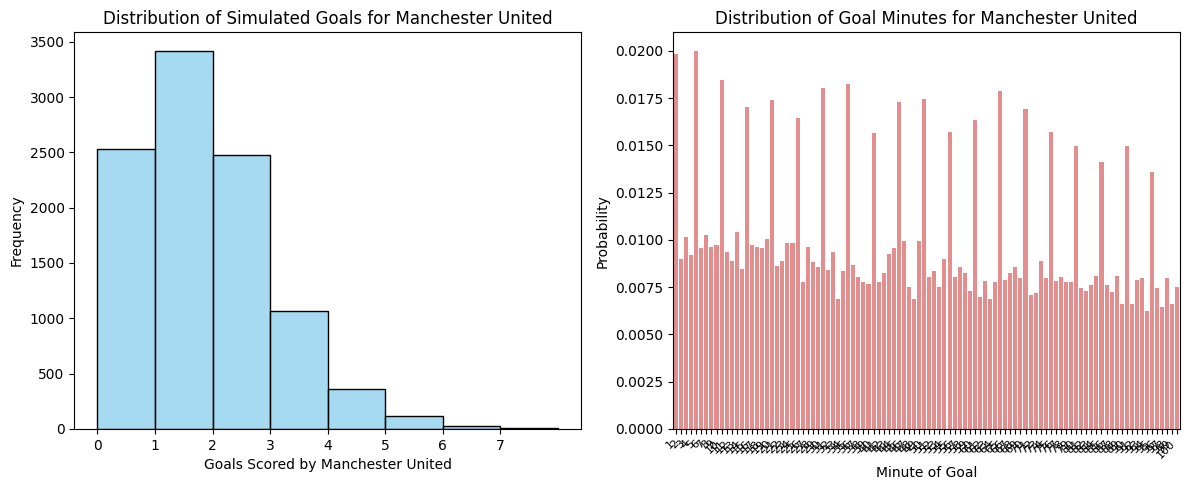

In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Distribution of Simulated Goals
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(all_simulated_goals_per_match, bins=range(0, max(all_simulated_goals_per_match) + 2), kde=False, color='skyblue')
plt.title('Distribution of Simulated Goals for Manchester United')
plt.xlabel('Goals Scored by Manchester United')
plt.ylabel('Frequency')
plt.xticks(range(max(all_simulated_goals_per_match) + 1))

# Plot 2: Distribution of Goal Minutes
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x=goal_minutes_distribution.index, y=goal_minutes_distribution.values, color='lightcoral')
plt.title('Distribution of Goal Minutes for Manchester United')
plt.xlabel('Minute of Goal')
plt.ylabel('Probability')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
def predict_live(current_minute, cumulative_shots, cumulative_xG, mu_side_in_match):
    """
    Estimates the probability of scoring at least one goal in the next 10 minutes
    from the current_minute, using provided current cumulative stats.
    """
    total_lambda_for_10_min = 0.0

    # Determine the end minutes of the next two 5-minute intervals.
    # The +1 is to ensure that even if current_minute is exactly at an interval boundary,
    # the next interval is correctly identified.
    first_interval_end = int(np.ceil((current_minute + 1) / SIMULATION_INTERVAL_STEP) * SIMULATION_INTERVAL_STEP)
    second_interval_end = first_interval_end + SIMULATION_INTERVAL_STEP

    intervals_to_predict = []
    if first_interval_end <= MAX_PREDICTION_MINUTE:
        intervals_to_predict.append(first_interval_end)
    if second_interval_end <= MAX_PREDICTION_MINUTE:
        intervals_to_predict.append(second_interval_end)

    if not intervals_to_predict:
        return 0.0 # No more intervals to predict goals within 10 minutes

    # Initialize cumulative stats for prediction using the provided live values
    cum_shots_for_prediction = cumulative_shots
    cum_xG_for_prediction = cumulative_xG
    cum_fast_break_for_prediction = 0 # This feature is less dynamic in a live scenario without real-time updates

    # Predict lambda for each of the next two 5-minute intervals
    for i, interval_end_minute in enumerate(intervals_to_predict):
        current_X_data = {
            'const': 1,
            'minute_interval': interval_end_minute,
            'mu_side_in_match': mu_side_in_match,
            'cumulative_shots': cum_shots_for_prediction,
            'cumulative_xG': cum_xG_for_prediction,
            'cumulative_fast_break': cum_fast_break_for_prediction # Using the provided for the first interval, then updated with average
        }
        current_X_df = pd.DataFrame([current_X_data], columns=poisson_results.model.exog_names)
        lambda_pred_interval = poisson_results.predict(current_X_df)[0]
        total_lambda_for_10_min += lambda_pred_interval

        # For the second interval, update cumulative stats based on average interval contributions
        if interval_end_minute in avg_interval_contribution.index:
            cum_shots_for_prediction += avg_interval_contribution.loc[interval_end_minute, 'interval_shots']
            cum_xG_for_prediction += avg_interval_contribution.loc[interval_end_minute, 'interval_xG']
            cum_fast_break_for_prediction += avg_interval_contribution.loc[interval_end_minute, 'interval_fast_break']

    # Probability of at least one goal = 1 - P(zero goals)
    prob_at_least_one_goal = 1 - np.exp(-total_lambda_for_10_min)
    return prob_at_least_one_goal

# Example usage for the predict_live function
example_current_minute_live = 60
example_cumulative_shots_live = 10
example_cumulative_xG_live = 1.5
example_mu_side_live = 1 # Assuming Manchester United is playing home (side=1)

prob_next_10_min_live = predict_live(
    example_current_minute_live,
    example_cumulative_shots_live,
    example_cumulative_xG_live,
    example_mu_side_live
)

print(f"\nLive prediction: Probability of scoring in the next 10 minutes from minute {example_current_minute_live} "
      f"(with {example_cumulative_shots_live} shots, {example_cumulative_xG_live:.2f} xG, and side {example_mu_side_live}): {prob_next_10_min_live:.4f}")



Live prediction: Probability of scoring in the next 10 minutes from minute 60 (with 10 shots, 1.50 xG, and side 1): 0.2151


    1: Menunjukkan Manchester United bermain di kandang (home).
    2: Menunjukkan Manchester United bermain tandang (away).


In [ ]:
import pickle

with open("poisson_model.pkl", "wb") as f:
    pickle.dump(poisson_results, f)

avg_interval_contribution.to_pickle("avg_interval.pkl")

## Final Task

### Subtask:
Present the analysis, visualizations, and the live prediction function.


In [ ]:
import pickle
import pandas as pd

# Load and verify poisson_model.pkl
model_filename = "poisson_model.pkl"
with open(model_filename, "rb") as f:
    loaded_poisson_model = pickle.load(f)
print(f"'poisson_model.pkl' loaded successfully. Model summary:\n{loaded_poisson_model.summary()}")

'poisson_model.pkl' loaded successfully. Model summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:      goals_in_interval   No. Observations:                 2268
Model:                            GLM   Df Residuals:                     2262
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -625.30
Date:                Wed, 04 Mar 2026   Deviance:                       857.52
Time:                        06:41:30   Pearson chi2:                 1.92e+03
No. Iterations:                     7   Pseudo R-squ. (CS):            0.05474
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [ ]:
# Load and verify avg_interval.pkl
avg_interval_filename = "avg_interval.pkl"
loaded_avg_interval_contribution = pd.read_pickle(avg_interval_filename)
print(f"\n'avg_interval.pkl' loaded successfully. First 5 rows:\n")
display(loaded_avg_interval_contribution.head())


'avg_interval.pkl' loaded successfully. First 5 rows:



,interval_shots,interval_xG,interval_fast_break
minute_interval,,,
0,0.125000,0.000240,0.0
5,0.546296,0.060943,0.0
10,0.704348,0.051305,0.0
15,0.724138,0.066547,0.0
20,0.715447,0.075473,0.0


## Summary:

### Data Analysis Key Findings

*   **Data Preparation & Filtering**:
    *   The analysis focused on 130 unique matches involving Manchester United, encompassing 11,729 total events.
    *   Out of these, 6,215 events were directly initiated by Manchester United.
*   **Expected Goals (xG) Model Performance**:
    *   A Logistic Regression model was trained on 3,121 shot events to predict goal probability (xG).
    *   The model achieved a training accuracy of 0.9395 and a test accuracy of 0.9296, demonstrating good predictive capability for goal outcomes.
*   **Time-Varying Goal Rate**:
    *   The Poisson regression model revealed a significant negative correlation between `minute_interval` and the goal rate (coefficient: -0.0214, p < 0.001), indicating that Manchester United's instantaneous goal-scoring rate tends to decrease as the match progresses.
    *   Accumulated Expected Goals (`cumulative_xG`) was a strong positive predictor (coefficient: 1.3614, p < 0.001), signifying that higher quality chances (xG) substantially increase the probability of scoring in subsequent intervals.
    *   `cumulative_fast_break` showed a significant negative coefficient (-0.7372, p < 0.05), which warrants further investigation as intuitively fast breaks might be expected to increase goal probability.
    *   `mu_side_in_match` (home/away) and `cumulative_shots` were not statistically significant predictors in this model.
*   **Simulated Goal Probabilities for Manchester United**:
    *   Based on 10,000 Monte Carlo simulations, the probabilities for Manchester United scoring a certain number of goals in a match are: P(0 goals) = 0.2474, P(1 goal) = 0.3470, P(2 goals) = 0.2388, and P(3+ goals) = 0.1668.
*   **Live Prediction Capability**:
    *   The `predict_live` function provides real-time goal probability estimations. For example, at minute 60, with 10 cumulative shots, 1.5 cumulative xG, and playing at home, Manchester United's probability of scoring in the next 10 minutes is 0.2151.

### Insights or Next Steps

*   **Refine Fast Break Impact**: Investigate why `cumulative_fast_break` exhibits a negative correlation with goal rate. This could be due to data nuances, collinearity with other features, or perhaps Manchester United's fast breaks, while frequent, are not consistently high-quality scoring opportunities, suggesting a need for a more granular feature engineering for fast breaks.
*   **Model Expansion and Validation**: Incorporate opponent strength, match importance, or player-specific attributes into the model to enhance predictive accuracy. Additionally, validate the model's performance against actual match outcomes using metrics like Brier score or calibration plots to ensure its reliability in real-world scenarios.
